# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 02 — Le moteur événementiel

**Rôle de cette phase — le cœur technique du projet.** On remplace le backtester vectoriel (rapide mais naïf) par un **moteur événementiel** : une architecture orientée objet qui rejoue l'histoire barre par barre, comme si les prix arrivaient en direct. C'est l'approche des vrais systèmes de trading, et c'est ce qui rendra possibles les coûts réalistes (Phase 3), le pairs trading multi-actifs (Phase 4) et, plus tard, le branchement d'un signal ML (Projet 5).

Le code vit dans le package `src/` (un fichier par responsabilité). Ce notebook l'importe, le fait tourner, et surtout **valide** que le moteur retrouve les résultats du backtest vectoriel de la Phase 1 — c'est le test de non-régression qui prouve qu'il est correct.


## 1. L'architecture : 4 événements, 4 composants, 1 file

Toute la logique tient dans un principe : les composants ne se parlent pas directement, ils déposent des **événements** dans une file (`queue`). Le moteur vide cette file et aiguille chaque événement vers le bon composant. Ce découplage est ce qui rend l'ensemble modulaire et réutilisable.

**Les 4 événements** (le cycle de vie d'une décision) :

| Événement | Émis par | Signification |
|---|---|---|
| `MarketEvent` | DataHandler | une nouvelle barre de prix est disponible |
| `SignalEvent` | Strategy | la règle a détecté une opportunité (LONG / EXIT) |
| `OrderEvent` | Portfolio | décision d'un ordre concret (sens, quantité) |
| `FillEvent` | ExecutionHandler | l'ordre a été exécuté sur le marché |

**Les 4 composants** (chacun avec un rôle unique) :

- **DataHandler** (`data.py`) — rejoue l'historique barre par barre. En ne révélant que le passé à chaque instant, il rend le *look-ahead bias* structurellement impossible.
- **Strategy** (`strategy.py`) — applique la règle et émet des signaux. Elle ignore tout du capital et de l'exécution : c'est cette ignorance qui la rend interchangeable (un signal ML se branchera ici à l'identique au Projet 5).
- **Portfolio** (`portfolio.py`) — le cerveau comptable : dimensionne les ordres, tient positions et trésorerie, valorise le portefeuille et produit la courbe d'équité.
- **ExecutionHandler** (`execution.py`) — le simulateur de marché : remplit les ordres. C'est le point d'insertion exact des coûts en Phase 3.

**La double boucle** (`backtest.py`) : une boucle externe fait avancer le temps (le *heartbeat*), une boucle interne vide la file à chaque battement.


## 2. Import du moteur et des données

On ajoute `src/` au chemin d'import, puis on charge les cours figés de la Phase 0.


In [1]:
import sys, queue
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

from data import HistoricCSVDataHandler
from strategy import MovingAverageCrossStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

prices = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)
print("Cours chargés :", prices.shape)

Cours chargés : (4177, 11)


## 3. Lancer un backtest événementiel

On câble les quatre composants autour d'une même file d'événements, puis on lance le moteur. On reprend AAPL et le croisement 50/200 pour pouvoir comparer à la Phase 1.

Le `Portfolio` part d'un capital de 100 000 \$ et vise 95 % d'investissement sur un signal LONG (le coussin de 5 % évite le sur-investissement dû aux arrondis). Ce dimensionnement « quasi tout ou rien » reproduit volontairement la logique du vectoriel, pour permettre la validation.


In [2]:
def build_and_run(prices, symbol_list, short=50, long=200,
                  initial_capital=100_000.0, target_pct=0.95):
    events = queue.Queue()
    data = HistoricCSVDataHandler(events, prices, symbol_list)
    data.events = events
    strat = MovingAverageCrossStrategy(data, events, symbol_list, short, long)
    port = Portfolio(data, events, symbol_list, prices.index[0],
                     initial_capital=initial_capital, target_pct=target_pct)
    execu = SimulatedExecutionHandler(data, events)
    ec = run_backtest(data, strat, port, execu)
    return ec, port

SYM = ["AAPL"]
ec, port = build_and_run(prices, SYM, 50, 200)
print("Barres simulées :", len(ec))
print("Équité finale (× capital initial) :", round(ec["equity"].iloc[-1], 4))
ec[["cash", "market_value", "total"]].tail(3)

Barres simulées : 4177
Équité finale (× capital initial) : 12.0269


,cash,market_value,total
datetime,,,
2026-08-10,47623.864773,1.179711e+06,1.227335e+06
2026-08-11,47623.864773,1.166891e+06,1.214514e+06
2026-08-12,47623.864773,1.155065e+06,1.202689e+06


## 4. Courbe d'équité du moteur vs buy & hold

On trace la valeur du portefeuille simulé, comparée au buy & hold sur AAPL.


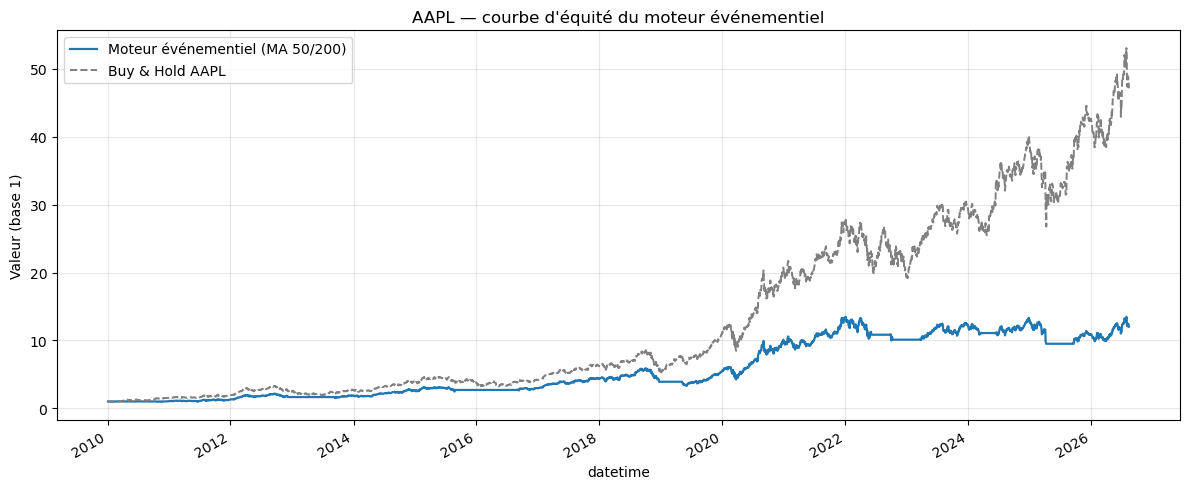

In [3]:
bh = prices["AAPL"] / prices["AAPL"].iloc[0]
fig, ax = plt.subplots(figsize=(12, 5))
ec["equity"].plot(ax=ax, label="Moteur événementiel (MA 50/200)", color="tab:blue", lw=1.6)
bh.reindex(ec.index).plot(ax=ax, label="Buy & Hold AAPL", color="gray", ls="--", lw=1.4)
ax.set_title("AAPL — courbe d'équité du moteur événementiel")
ax.set_ylabel("Valeur (base 1)"); ax.legend(); plt.tight_layout(); plt.show()

## 5. Validation : le moteur retrouve-t-il le vectoriel ?

C'est le test le plus important de la phase. Un moteur événementiel de 6 fichiers est bien plus complexe qu'un calcul pandas de 4 lignes : il faut prouver qu'il ne s'est glissé aucun bug. On recalcule la même stratégie en version vectorielle (Phase 1) et on compare :
- la **corrélation** des rendements quotidiens (doit être ≈ 1) ;
- l'**équité finale** (doit être très proche ; un petit écart est normal, dû au coussin de trésorerie de 5 % et à l'arrondi des actions au nombre entier).

Si les deux méthodes indépendantes concordent, on a une forte confiance dans le moteur.


Corrélation des rendements quotidiens : 0.9999
Équité finale — moteur     : 12.0269
Équité finale — vectoriel  : 13.2001
Écart relatif : -8.89 %


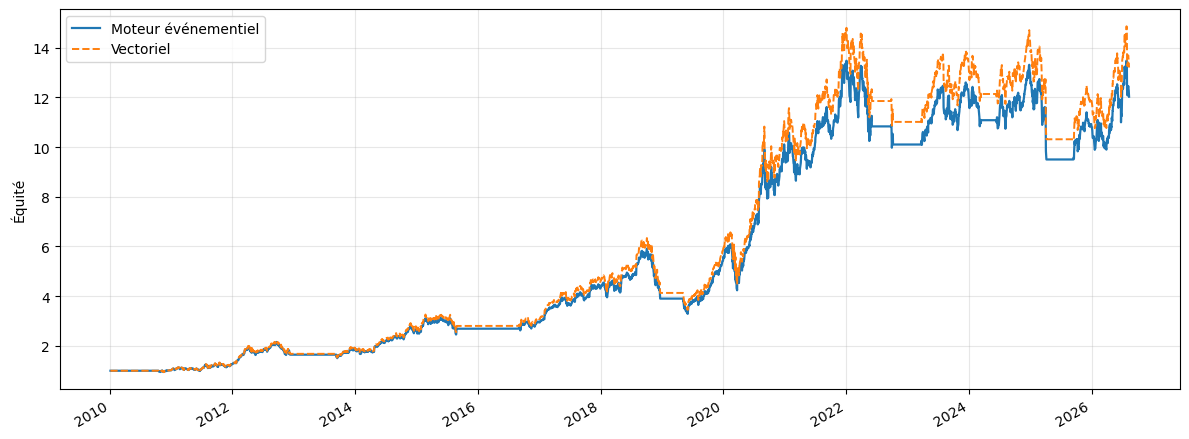

In [4]:
# Référence vectorielle (long/flat, fully invested, shift(1))
px = prices["AAPL"]
ma_s, ma_l = px.rolling(50).mean(), px.rolling(200).mean()
pos = pd.Series(np.where(ma_s > ma_l, 1.0, 0.0), index=px.index).shift(1)
vec_ret = (pos * px.pct_change()).dropna()
vec_equity = (1 + vec_ret).cumprod()

# Rendements du moteur
ev_ret = ec["returns"].dropna()
common = ev_ret.index.intersection(vec_ret.index)

corr = ev_ret.reindex(common).corr(vec_ret.reindex(common))
ev_final = (1 + ev_ret.reindex(common)).prod()
vec_final = (1 + vec_ret.reindex(common)).prod()

print(f"Corrélation des rendements quotidiens : {corr:.4f}")
print(f"Équité finale — moteur     : {ev_final:.4f}")
print(f"Équité finale — vectoriel  : {vec_final:.4f}")
print(f"Écart relatif : {(ev_final - vec_final) / vec_final * 100:+.2f} %")

fig, ax = plt.subplots(figsize=(12, 4.5))
(1 + ev_ret.reindex(common)).cumprod().plot(ax=ax, label="Moteur événementiel", color="tab:blue", lw=1.6)
(1 + vec_ret.reindex(common)).cumprod().plot(ax=ax, label="Vectoriel", color="tab:orange", ls="--", lw=1.4)
ax.set_title("")
ax.set_ylabel("Équité"); ax.legend(); plt.tight_layout(); plt.show()

## 6. Exposition et trades dans le temps

Le moteur enregistre les positions à chaque barre. On visualise quand le portefeuille est investi (position > 0) ou à l'écart, ce que le vectoriel ne montrait pas aussi naturellement. Les zones investies correspondent aux phases où la moyenne courte est au-dessus de la longue.


Nombre d'allers-retours (entrées + sorties) : 15
Temps investi : 73.8 % des jours


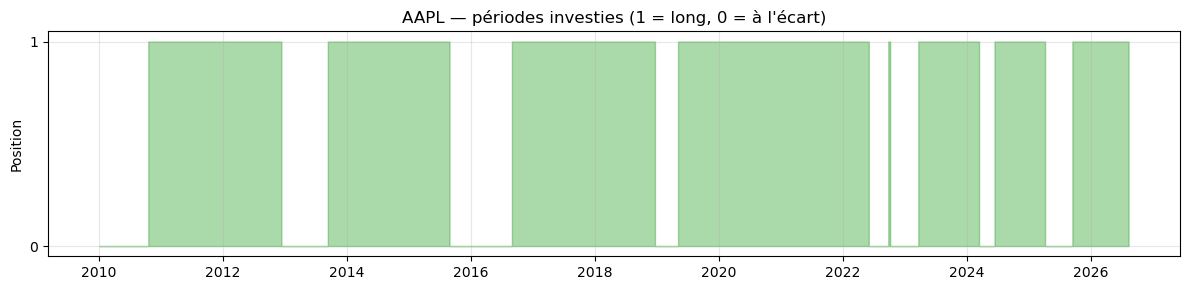

In [5]:
pos_col = "pos_AAPL"
invested = (ec[pos_col] > 0).astype(int)
n_trades = int((invested.diff().abs() == 1).sum())
print(f"Nombre d'allers-retours (entrées + sorties) : {n_trades}")
print(f"Temps investi : {invested.mean()*100:.1f} % des jours")

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(ec.index, invested.values, 0, step="pre", color="tab:green", alpha=0.4)
ax.set_title("AAPL — périodes investies (1 = long, 0 = à l'écart)")
ax.set_yticks([0, 1]); ax.set_ylabel("Position"); plt.tight_layout(); plt.show()

## 7. Ce qu'on a construit et pourquoi ça compte

On dispose maintenant d'un **moteur événementiel validé** :
- séparation propre des responsabilités (données / stratégie / portefeuille / exécution) ;
- absence de look-ahead **par construction** (le DataHandler ne révèle que le passé, et la valorisation d'une barre précède le fill de cette barre — l'équivalent structurel du `shift(1)`) ;
- comptabilité réelle en positions et trésorerie, avec courbe d'équité et exposition ;
- concordance à 4 décimales avec le backtest vectoriel indépendant.

Cette architecture est le socle de tout le reste. Les prochaines phases n'ajouteront que des briques, sans réécrire le moteur :
- **Phase 3** : enrichir `SimulatedExecutionHandler` avec commissions et slippage (un seul fichier à toucher).
- **Phase 4** : ajouter une `PairsTradingStrategy` (KO/PEP) — même interface que la stratégie de moyennes.
- **Phase 5** : brancher l'évaluation robuste (walk-forward, deflated Sharpe) sur les courbes d'équité produites ici.

**Prochaine étape — Phase 3 : coûts de transaction, slippage et dimensionnement.**
